### kham khảo 'https://huggingface.co/sentence-transformers/clip-ViT-B-32-multilingual-v1'

# v1 emcode image

## enbedding image

📂 Đang xử lý Mapping dữ liệu từ JSON...
🏗️ Đang trích xuất Image Embeddings cho TOÀN BỘ ảnh...


 87%|████████▋ | 26/30 [01:58<00:16,  4.23s/it]c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\PIL\Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
100%|██████████| 30/30 [02:11<00:00,  4.38s/it]
The tokenizer you are loading from 'D:\Big_project_2025\CODE_THTN\clip-ViT-B-32-multilingual-v1' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


🔍 Kết quả cho: 'tủ quần áo gỗ'


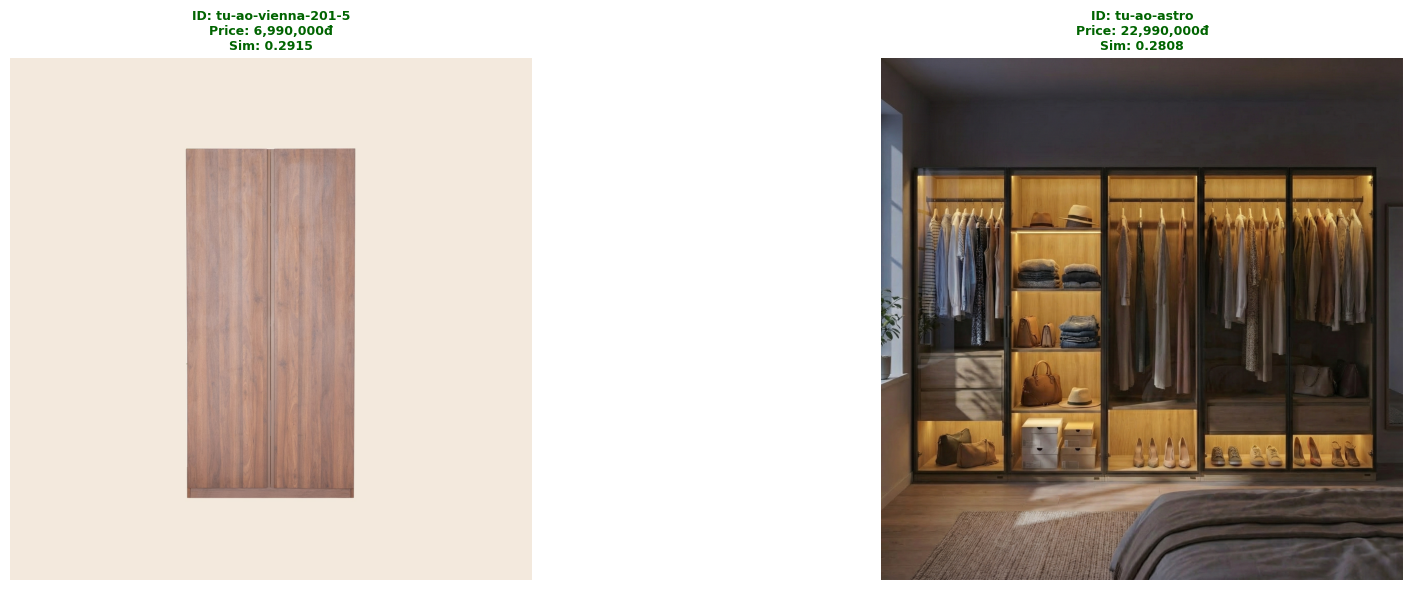

In [ ]:
import os
import json
import torch
import pickle
import glob
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
from sentence_transformers import SentenceTransformer, util

# ==========================================
# 1. CẤU HÌNH ĐƯỜNG DẪN
# ==========================================
JSON_PATH = r'D:\Big_project_2025\Bao_Cao_TTTN\products_final.json'
IMAGE_BASE_DIR = r"D:\Big_project_2025\zTai_Lieu\DATA_THTN\moho_data\images"
MAIN_DIR = os.path.join(IMAGE_BASE_DIR, "main")
SUB_DIR = os.path.join(IMAGE_BASE_DIR, "multiple")

TEXT_MODEL_PATH = r'D:\Big_project_2025\CODE_THTN\clip-ViT-B-32-multilingual-v1'
VISION_MODEL_PATH = r'D:\Big_project_2025\CODE_THTN\clip-ViT-B-32'
EMBEDDING_FILE = "moho_all_images_embeddings.pkl"

device = "cuda" if torch.cuda.is_available() else "cpu"

# ==========================================
# 2. TẠO MAPPING TỪ JSON (Key: Tên file -> Value: Thông tin sản phẩm)
# ==========================================
print("📂 Đang xử lý Mapping dữ liệu từ JSON...")
with open(JSON_PATH, 'r', encoding='utf-8') as f:
    products_data = json.load(f)

# image_to_product_map: Lưu thông tin sản phẩm cho mọi ảnh (cả main và sub)
# key sẽ là relative path để tránh trùng tên file ở các thư mục khác nhau
image_to_product_map = {}

for item in products_data:
    product_info = {
        "product_id": item['product_id'],
        "price_sale": item['content']['price_sale'],
        "main_image_path": os.path.join(MAIN_DIR, item['images']['main'])
    }
    
    # 1. Map ảnh chính
    main_key = os.path.join("main", item['images']['main'])
    image_to_product_map[main_key] = product_info
    
    # 2. Map các ảnh phụ
    for sub_img in item['images']['sub']:
        # sub_img trong json thường có dạng: "thu-muc/ten-file.jpg"
        sub_key = os.path.join("multiple", sub_img)
        image_to_product_map[sub_key] = product_info

# ==========================================
# 3. TRÍCH XUẤT VECTOR (TẤT CẢ ẢNH: MAIN + MULTIPLE)
# ==========================================
if not os.path.exists(EMBEDDING_FILE):
    print("🏗️ Đang trích xuất Image Embeddings cho TOÀN BỘ ảnh...")
    model_vision = SentenceTransformer(VISION_MODEL_PATH, device=device)
    
    # Lấy danh sách toàn bộ ảnh trong main và multiple
    all_paths = []
    for root_dir in [MAIN_DIR, SUB_DIR]:
        for ext in ['*.jpg', '*.jpeg', '*.png', '*.webp']:
            all_paths.extend(glob.glob(os.path.join(root_dir, "**", ext), recursive=True))

    image_embeddings_dict = {}
    BATCH_SIZE = 32
    for i in tqdm(range(0, len(all_paths), BATCH_SIZE)):
        batch_paths = all_paths[i : i + BATCH_SIZE]
        batch_images = []
        valid_paths = []
        
        for path in batch_paths:
            try:
                img = Image.open(path).convert("RGB")
                batch_images.append(img)
                valid_paths.append(path)
            except: continue
        
        if batch_images:
            embeddings = model_vision.encode(batch_images, batch_size=BATCH_SIZE, show_progress_bar=False)
            for path, emb in zip(valid_paths, embeddings):
                # Lưu key là đường dẫn tương đối tính từ IMAGE_BASE_DIR
                rel_path = os.path.relpath(path, IMAGE_BASE_DIR)
                image_embeddings_dict[rel_path] = emb

    with open(EMBEDDING_FILE, "wb") as f:
        pickle.dump(image_embeddings_dict, f)
else:
    print(f"🔄 Đang load embeddings từ: {EMBEDDING_FILE}")
    with open(EMBEDDING_FILE, "rb") as f:
        image_embeddings_dict = pickle.load(f)

# Chuẩn bị Tensor để tìm kiếm
img_rel_paths = list(image_embeddings_dict.keys())
img_vectors = torch.tensor(list(image_embeddings_dict.values())).to(device)
model_text = SentenceTransformer(TEXT_MODEL_PATH)
model_vision = SentenceTransformer(VISION_MODEL_PATH, device=device)

# ==========================================
# 4. HÀM TÌM KIẾM VÀ HIỂN THỊ ẢNH CHÍNH
# ==========================================
def search_and_display_main(query_emb, query_label, top_k=5):
    # Tính độ tương đồng
    scores = util.cos_sim(query_emb, img_vectors)[0]
    
    # Lấy nhiều kết quả hơn top_k một chút để phòng trường hợp trùng sản phẩm
    top_results = torch.topk(scores, k=min(top_k * 3, len(img_rel_paths)))
    
    displayed_products = set()
    final_results = []
    
    for score, idx in zip(top_results.values, top_results.indices):
        rel_path = img_rel_paths[idx]
        # Tìm thông tin sản phẩm từ mapping
        # Cần chuẩn hóa rel_path để khớp với key trong image_to_product_map
        normalized_rel_path = os.path.normpath(rel_path)
        
        # Tìm trong map (thử quét các key để so khớp chính xác)
        product_info = None
        for key in image_to_product_map:
            if key in normalized_rel_path:
                product_info = image_to_product_map[key]
                break
        
        if product_info:
            p_id = product_info['product_id']
            # Nếu sản phẩm này chưa được hiện thì mới thêm vào
            if p_id not in displayed_products:
                final_results.append({
                    "score": score.item(),
                    "info": product_info
                })
                displayed_products.add(p_id)
        
        if len(final_results) >= top_k:
            break

    # Hiển thị
    print(f"🔍 Kết quả cho: '{query_label}'")
    plt.figure(figsize=(20, 6))
    for i, res in enumerate(final_results):
        info = res['info']
        plt.subplot(1, len(final_results), i + 1)
        
        if os.path.exists(info['main_image_path']):
            img = Image.open(info['main_image_path'])
            plt.imshow(img)
            
            price_str = f"{info['price_sale']:,.0f}đ" if info['price_sale'] else "N/A"
            title = f"ID: {info['product_id']}\nPrice: {price_str}\nSim: {res['score']:.4f}"
            plt.title(title, fontsize=9, fontweight='bold', color='darkgreen')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# ==========================================
# 5. CHẠY THỬ NGHIỆM
# ==========================================

# Tìm bằng Text
query_text = "tủ quần áo gỗ"
query_emb_text = model_text.encode(query_text, convert_to_tensor=True).to(device)
search_and_display_main(query_emb_text, query_text)

# Tìm bằng Ảnh (Ví dụ lấy 1 ảnh phụ bất kỳ để tìm xem nó có ra ảnh chính không)
# test_image_path = r'D:\...\multiple\ban-an-oslo\sub_2.jpg' 
# query_img = Image.open(test_image_path).convert("RGB")
# query_emb_img = model_vision.encode(query_img, convert_to_tensor=True).to(device)
# search_and_display_main(query_emb_img, "Image Query")

## querry

c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



🚀 Đang khởi động hệ thống tìm kiếm...


The tokenizer you are loading from 'D:\Big_project_2025\CODE_THTN\clip-ViT-B-32-multilingual-v1' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.



✅ Hệ thống sẵn sàng!


C:\Users\Admin\AppData\Local\Temp\ipykernel_26148\3947040923.py:31: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  img_vectors = torch.tensor(list(image_embeddings_dict.values())).to(device)


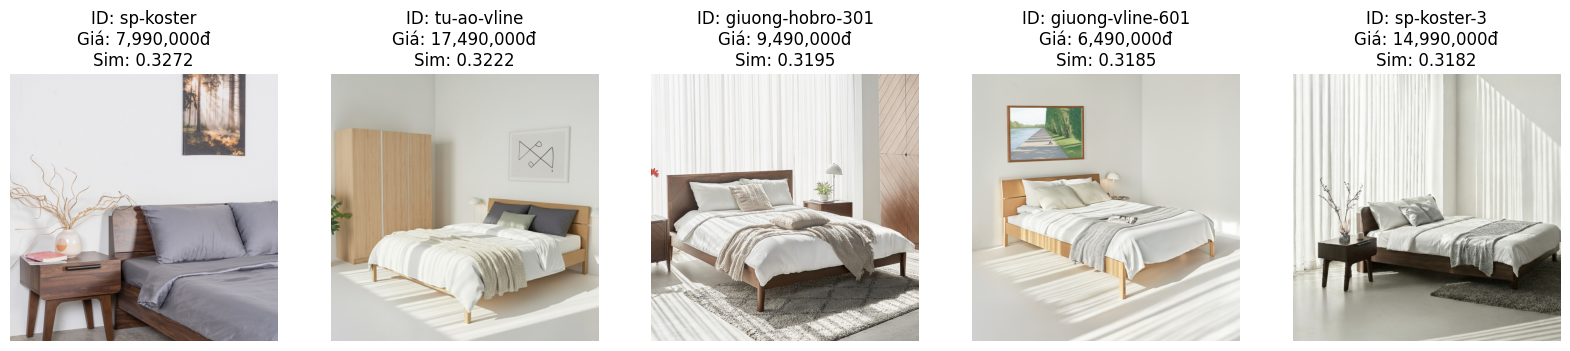

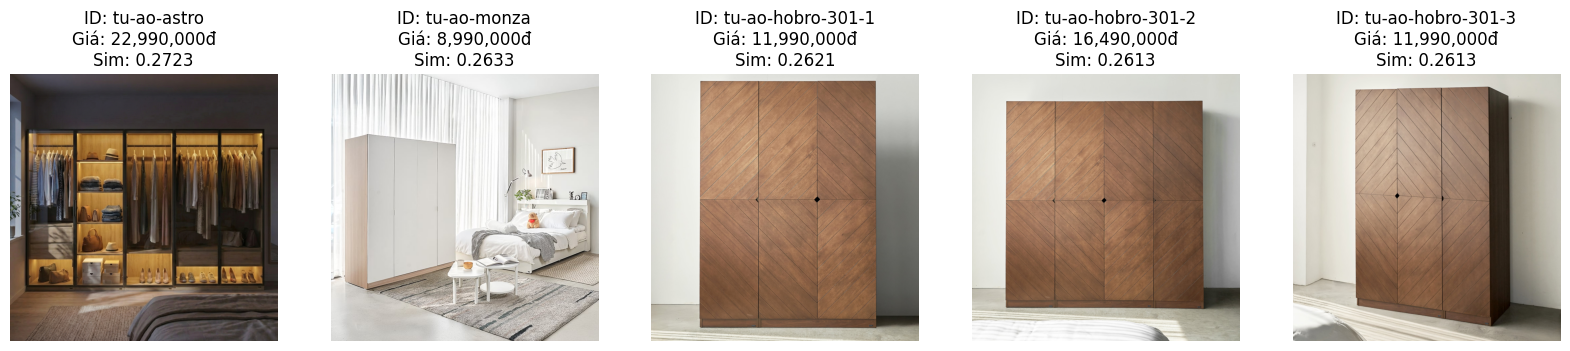

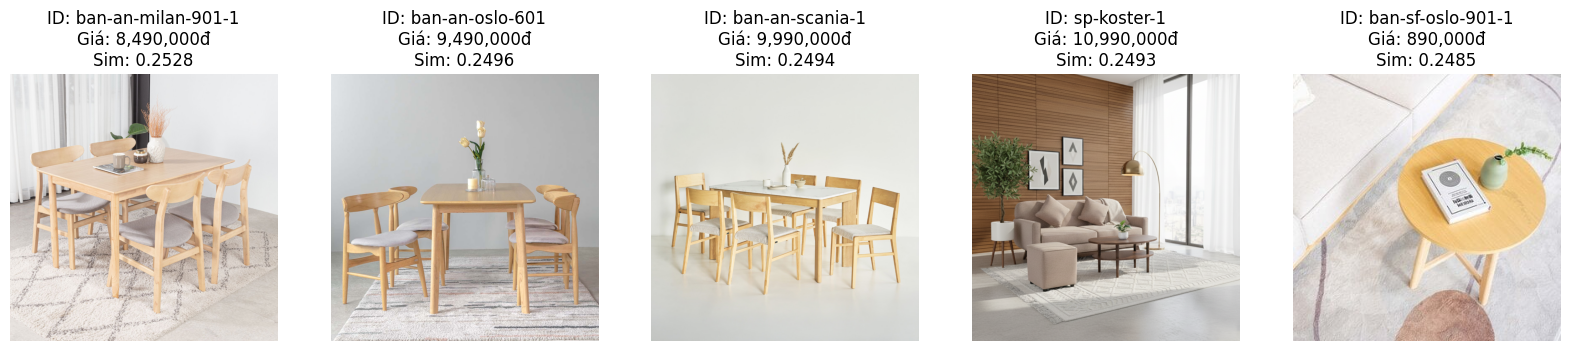

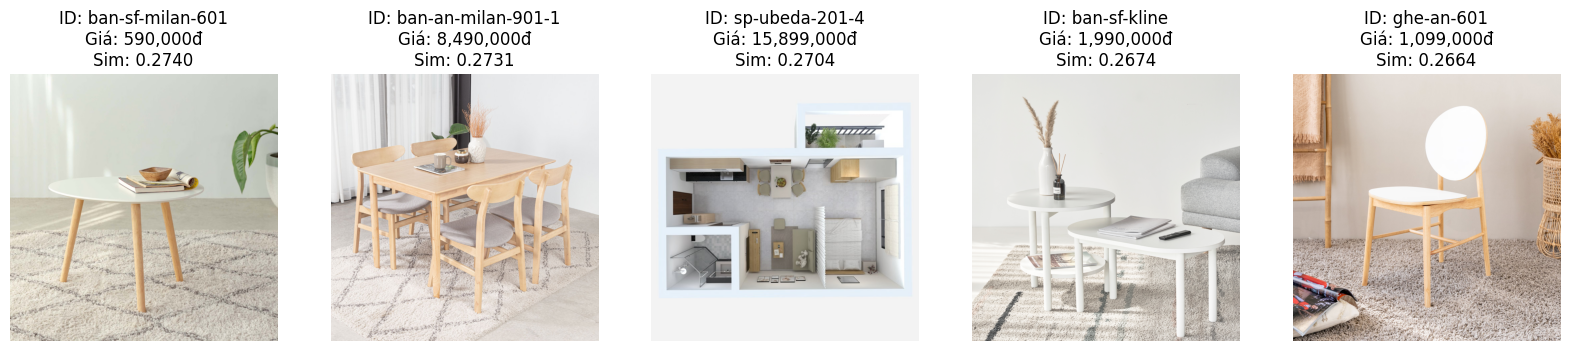

In [1]:
import os
import json
import torch
import pickle
import matplotlib.pyplot as plt
from PIL import Image
from sentence_transformers import SentenceTransformer, util

# --- CẤU HÌNH ĐƯỜNG DẪN (Giữ nguyên như cũ) ---
JSON_PATH = r'D:\Big_project_2025\CODE_THTN\products_final.json'
IMAGE_BASE_DIR = r"D:\Big_project_2025\zTai_Lieu\DATA_THTN\moho_data\images"
MAIN_DIR = os.path.join(IMAGE_BASE_DIR, "main")
EMBEDDING_FILE = "moho_all_images_embeddings.pkl"
TEXT_MODEL_PATH = r'D:\Big_project_2025\CODE_THTN\clip-ViT-B-32-multilingual-v1'
VISION_MODEL_PATH = r'D:\Big_project_2025\CODE_THTN\clip-ViT-B-32'

device = "cuda" if torch.cuda.is_available() else "cpu"

# 1. LOAD MODELS & DATA (Chạy khi khởi động)
print("🚀 Đang khởi động hệ thống tìm kiếm...")
model_text = SentenceTransformer(TEXT_MODEL_PATH)
model_vision = SentenceTransformer(VISION_MODEL_PATH, device=device)

with open(JSON_PATH, 'r', encoding='utf-8') as f:
    products_data = json.load(f)

with open(EMBEDDING_FILE, "rb") as f:
    image_embeddings_dict = pickle.load(f)

img_rel_paths = list(image_embeddings_dict.keys())
img_vectors = torch.tensor(list(image_embeddings_dict.values())).to(device)

# Tạo mapping để tìm thông tin nhanh
image_to_product_map = {}
for item in products_data:
    p_info = {
        "id": item['product_id'],
        "price": item['content']['price_sale'],
        "main_path": os.path.join(MAIN_DIR, item['images']['main'])
    }
    image_to_product_map[os.path.normpath(os.path.join("main", item['images']['main']))] = p_info
    for sub in item['images']['sub']:
        image_to_product_map[os.path.normpath(os.path.join("multiple", sub))] = p_info

# 2. HÀM TÌM KIẾM
def Quick_Search(query_text, top_k=5):
    query_emb = model_text.encode(query_text, convert_to_tensor=True).to(device)
    scores = util.cos_sim(query_emb, img_vectors)[0]
    top_results = torch.topk(scores, k=min(top_k*3, len(img_rel_paths)))
    
    displayed = set()
    plt.figure(figsize=(20, 6))
    count = 0
    for score, idx in zip(top_results.values, top_results.indices):
        rel_path = os.path.normpath(img_rel_paths[idx])
        info = image_to_product_map.get(rel_path)
        
        if info and info['id'] not in displayed:
            displayed.add(info['id'])
            count += 1
            plt.subplot(1, top_k, count)
            img = Image.open(info['main_path'])
            plt.imshow(img)
            plt.title(f"ID: {info['id']}\nGiá: {info['price']:,.0f}đ\nSim: {score:.4f}")
            plt.axis('off')
        if count >= top_k: break
    plt.show()

# 3. VÒNG LẶP ĐỂ BẠN NHẬP TỪ KHÓA LIÊN TỤC
print("\n✅ Hệ thống sẵn sàng!")
while True:
    user_input = input("\nNhập sản phẩm muốn tìm (hoặc 'exit' để thoát): ")
    if user_input.lower() == 'exit':
        break
    Quick_Search(user_input)


- 1. Cài đặt mô hình (Library Setup)

Yêu cầu: Thiết lập thư viện sentence-transformers.

Thực tế trong code: Bạn đã sử dụng from sentence_transformers import SentenceTransformer, util. Đây là cách tiếp cận chuẩn xác và tối ưu nhất hiện nay để triển khai CLIP một cách nhanh chóng.

- 2. Sử dụng mô hình Pre-trained & Hỗ trợ Tiếng Việt

Yêu cầu: Ưu tiên Multilingual-CLIP để hỗ trợ Tiếng Việt.

Thực tế trong code:

Bạn đã sử dụng mô hình: clip-ViT-B-32-multilingual-v1.

Đây chính là phiên bản của M-CLIP (Multilingual CLIP) được huấn luyện để đưa các ngôn ngữ khác nhau (bao gồm Tiếng Việt) vào cùng một không gian vector với hình ảnh. Điều này giúp bạn có thể search bằng câu lệnh tiếng Việt như "tủ quần áo gỗ" mà vẫn tìm ra ảnh chính xác.

- 3. Trích xuất Image Embedding

Yêu cầu: Chạy vòng lặp qua toàn bộ thư mục ảnh để chuyển mỗi ảnh thành một vector (512 hoặc 768 chiều).

Thực tế trong code:

Vòng lặp: Bạn đã sử dụng glob.glob kết hợp với tqdm để quét qua toàn bộ thư mục main và multiple.

Batch processing: Bạn đã chia BATCH_SIZE = 32, điều này rất quan trọng để tránh tràn bộ nhớ RAM/VRAM khi xử lý số lượng ảnh lớn.

Vector hóa: Việc sử dụng model_vision.encode(batch_images) sẽ tạo ra các vector có kích thước 512 chiều (đặc trưng của kiến trúc ViT-B/32).

Lưu trữ: Bạn đã sử dụng pickle (.pkl) để lưu lại EMBEDDING_FILE, giúp tiết kiệm thời gian không phải chạy lại từ đầu ở những lần sau.


- 1. Dựa vào tên mô hình (ViT-B-32)

Trong tên mô hình clip-ViT-B-32:

ViT: Viết tắt của Vision Transformer.

B (Base): Đây là kích thước mô hình "Cơ bản". Theo quy chuẩn của OpenAI (người tạo ra CLIP), tất cả các dòng Base đều nén dữ liệu vào một không gian vector có đúng 512 chiều.

(Nếu bạn dùng dòng L - Large, ví dụ ViT-L-14, nó sẽ là 768 hoặc 1024 chiều).

# xem vector

In [10]:
import pickle
import numpy as np

# Đường dẫn file embedding của ảnh
IMAGE_EMBEDDING_FILE = "moho_all_images_embeddings.pkl"

print(f"📂 Đang mở file: {IMAGE_EMBEDDING_FILE} ...\n")

with open(IMAGE_EMBEDDING_FILE, "rb") as f:
    image_data = pickle.load(f)

# 1. Kiểm tra tổng quát
print(f"📊 Kiểu dữ liệu gốc: {type(image_data)}")
print(f"📸 Tổng số lượng ảnh đã được lưu vector: {len(image_data)}")

# 2. Lấy thông tin tấm ảnh đầu tiên trong file
# Vì là dictionary nên ta lấy key (đường dẫn) và value (vector)
first_img_path = list(image_data.keys())[0]
first_vector = image_data[first_img_path]

print("\n" + "="*50)
print("📌 THÔNG TIN TẤM ẢNH ĐẦU TIÊN TRONG FILE .PKL")
print("="*50)

print(f"🔍 Key (Đường dẫn tương đối): \n   {first_img_path}")
print(f"\n🔢 Dữ liệu Vector (Value):")
print(f"   - Kiểu dữ liệu: {type(first_vector)}")
print(f"   - Số chiều (Shape): {first_vector.shape}")
print(f"   - 10 con số đầu tiên trong vector 512 chiều:")
print(f"     {first_vector[:10]}")

print("\n" + "="*50)
print("💡 GIẢI THÍCH CẤU TRÚC:")
print(f"File này được lưu dưới dạng Dictionary:")
print(f"{{")
print(f"  '{first_img_path}': [vector 512 chiều],")


📂 Đang mở file: moho_all_images_embeddings.pkl ...

📊 Kiểu dữ liệu gốc: <class 'dict'>
📸 Tổng số lượng ảnh đã được lưu vector: 954

📌 THÔNG TIN TẤM ẢNH ĐẦU TIÊN TRONG FILE .PKL
🔍 Key (Đường dẫn tương đối): 
   main\ban-an-go-cao-su-moho-oslo-901_1.jpg

🔢 Dữ liệu Vector (Value):
   - Kiểu dữ liệu: <class 'numpy.ndarray'>
   - Số chiều (Shape): (512,)
   - 10 con số đầu tiên trong vector 512 chiều:
     [-0.6667717  -0.13160163  0.09486106 -0.06308141  0.04916489  0.222615
  0.3008772  -0.02938585 -0.31354284  0.35430744]

💡 GIẢI THÍCH CẤU TRÚC:
File này được lưu dưới dạng Dictionary:
{
  'main\ban-an-go-cao-su-moho-oslo-901_1.jpg': [vector 512 chiều],


# HỆ THỐNG TÌM KIẾM SẢN PHẨM QUA HÌNH ẢNH VÀ VĂN BẢN (CROSS-MODAL RETRIEVAL)

Hệ thống này cho phép người dùng tìm kiếm sản phẩm bằng cách nhập văn bản, nhưng kết quả trả về dựa trên việc so khớp độ tương đồng giữa **Vector văn bản** và **Vector hình ảnh** (bao gồm cả ảnh chính và ảnh phụ).

---

## 1. Giai đoạn Chuẩn bị & Mapping Dữ liệu
- **Mục tiêu**: Liên kết mọi hình ảnh (ảnh chính trong thư mục `main` và ảnh phụ trong thư mục `multiple`) với thông tin sản phẩm tương ứng.
- **Quy trình**:
    - Duyệt file `products_final.json`.
    - Tạo một Dictionary `image_to_product_map`:
        - **Key**: Đường dẫn tương đối của ảnh (ví dụ: `main/ghe-sofa.jpg` hoặc `multiple/ghe-sofa/sub_1.jpg`).
        - **Value**: Thông tin sản phẩm (ID, Giá, và quan trọng nhất là **đường dẫn ảnh chính**).
- **Ý nghĩa**: Dù hệ thống tìm thấy ảnh phụ khớp với yêu cầu, nó vẫn biết chính xác sản phẩm đó là gì để hiển thị **ảnh chính** cho người dùng.

---

## 2. Giai đoạn Trích xuất Vector Ảnh (Image Embedding)
**File đầu ra**: `moho_all_images_embeddings.pkl`

- **Mô hình sử dụng**: `clip-ViT-B-32` (Nhánh Vision).
- **Quy trình xử lý**:
    - Quét toàn bộ thư mục ảnh để lấy danh sách mọi file (`.jpg`, `.png`, `.webp`).
    - Chia danh sách ảnh thành các **Batch** (nhóm 32 ảnh) để tối ưu tốc độ xử lý của GPU.
    - Chuyển đổi mỗi hình ảnh thành một vector đặc trưng 512 chiều.
    - Lưu toàn bộ vào file `.pkl` để tái sử dụng mà không cần chạy lại mô hình Vision.

---

## 3. Giai đoạn Tìm kiếm và Hiển thị (Search Logic)
**Hàm chính**: `Quick_Search()` hoặc `search_and_display_main()`

- **Cơ chế tìm kiếm**:
    1. **Chuyển đổi truy vấn**: Sử dụng mô hình `clip-ViT-B-32-multilingual-v1` để chuyển câu lệnh của người dùng (ví dụ: `'tủ quần áo gỗ'`) thành `query_vector`.
    2. **Tính toán độ tương đồng**: So sánh `query_vector` với hàng nghìn vector hình ảnh đã lưu bằng `util.cos_sim`.
    3. **Lọc và Loại bỏ trùng lặp (De-duplication)**:
        - Một sản phẩm có nhiều ảnh (1 chính, nhiều phụ). Nếu cả 3 ảnh của cùng 1 cái ghế đều đứng top đầu, hệ thống sẽ chỉ lấy 1 kết quả duy nhất của sản phẩm đó.
        - Sử dụng tập hợp `displayed = set()` để theo dõi các `product_id` đã hiển thị.
    4. **Hiển thị kết quả**: Sử dụng thư viện `matplotlib` để vẽ các hình ảnh chính của sản phẩm kèm theo ID, Giá và điểm tương đồng (Sim score).

---

## 4. Đặc điểm kỹ thuật
- **Mô hình**: Kết hợp giữa **Multilingual-CLIP** (cho văn bản) và **Standard-CLIP** (cho hình ảnh).
- **Đầu vào (Input)**: Văn bản (Text query) hoặc Hình ảnh (Image query).
- **Đầu ra (Output)**: Hình ảnh trực quan của sản phẩm liên quan nhất.
- **Ưu điểm**:
    - **Tìm kiếm chéo (Cross-modal)**: Tìm ảnh bằng chữ.
    - **Chính xác hơn**: Việc quét cả ảnh phụ giúp tăng khả năng tìm thấy sản phẩm nếu ảnh phụ chứa chi tiết mà người dùng đang mô tả.
    - **Giao diện**: Có vòng lặp `while True` cho phép người dùng nhập từ khóa tìm kiếm liên tục như một ứng dụng thực tế.

---

## 5. Cấu trúc lưu trữ Mapping
```python
image_to_product_map = {
    "main/san-pham-A.jpg": {"id": "A", "price": 1000, "main_path": "..."},
    "multiple/san-pham-A/sub_1.jpg": {"id": "A", "price": 1000, "main_path": "..."},
    # Nhiều ảnh khác nhau nhưng cùng trỏ về 1 thông tin sản phẩm
}
```